# 数据增强  
数据增强是指通过对原始数据进行一系列变换和处理，生成更多、更丰富的训练样本的技术方法。数据增强在机器学习和深度学习领域中被广泛应用，它可以有效地解决数据不足的问题，提高模型的泛化能力和鲁棒性。我们已经了解了卷积神经网络 (Convolutional Neural Network, CNN) 有助于解决图像平移问题，但如果平移的范围过大同样可能影响模型的性能。在本节中，我们将学习如何使用数据增强确保模型能够得到正确的预测结果，即使图像移动较大范围。

## 1. 图像增强  
数据增强的目的是通过对原始数据进行合理的变换，生成新的样本，使得这些样本在保持原始类别标签不变的情况下，尽可能涵盖更多的数据特征和变化情况。在计算机视觉领域，对于给定的图像，即使我们平移，旋转或缩放图像，图像的标签也将保持不变。  
​  
基于上述原理，数据增强是从给定的图像集中创建更多图像的一种方法，即通过旋转，平移或缩放它们并将它们映射到原始图像的标签，以扩充数据集。通过随机平移输入图像并将它们传递给网络来训练神经网络，相同的图像将在不同批次中作为不同的图像处理，因为在每个批次中具有不同的平移量。我们已经了解了图像平移对模型预测准确性的影响。但是，在现实世界中，我们可能会遇到其他多种图像变换的情况：

- 图像旋转​
- 图像缩放​
- 图片翻转​
- 图像剪切​
- 图像中存在噪点​
- 图像亮度较低/高​  

    如果不考虑以上情况，训练出的神经网络并不会得到准确的预测结果。图像增强根据给定图像创建更多图像，通过旋转、平移、缩放、添加噪声和亮度等修改原始图像，此外，可以使用不同的参数指定图像的变化程度(例如，某个图像的平移可以是 +10 像素，也可以是 -5 像素)。imgaug 库中的 augmenters 类可以用于实现数据增强，常用的数据增强技术如下：·​
- 仿射变换​
- 亮度修改​
- 添加噪音

PyTorch 中同样包含图像增强管道 torchvision.transforms。但是，imgaug 包含更多选项，且易于解释数据增强功能，可以使用 pip 命令安装 imgaug 库：​

In [2]:
pip install imgaug

Note: you may need to restart the kernel to use updated packages.


### 1.1 仿射变换  
仿射变换包括平移、旋转、缩放和剪切图像，可以使用 augmenters 类中的 Affine 方法执行仿射变换。Affine 方法中包含以下重要参数：  ​
- scale：要对图像进行的缩放量​
- translate_percent： 将平移量指定为图像高度和宽度的百分比​
- translate_px：将平移量指定为绝对像素数​
- rotate：要在图像上完成的旋转量​
- shear：要在图像的一部分上完成的旋转量

1. 从 Fashion-MNIST 数据集中获取随机图像：

0.4.0


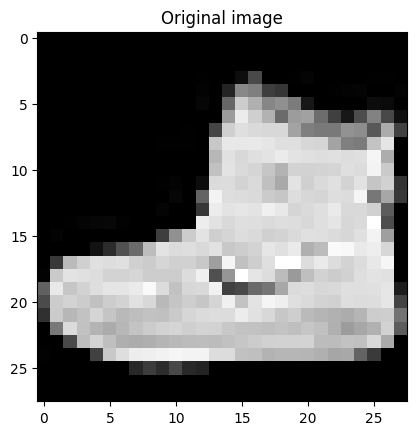

In [7]:
import imgaug
import imgaug.augmenters as iaa
print(imgaug.__version__)

from torchvision import datasets
import torch
data_folder = './data/MNIST'
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)

tr_images = fmnist.data
tr_targets = fmnist.targets

import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
device = 'cpu'

def to_numpy(tensor):
    return tensor.cpu().detach().numpy()

plt.imshow(tr_images[0], cmap='gray')
plt.title('Original image')
plt.show()

2. 定义用于执行缩放的对象 aug：

In [8]:
aug = iaa.Affine(scale=2)

3. 指定使用 aug 对象中的 augment_image 方法执行图像增强，并进行绘制：

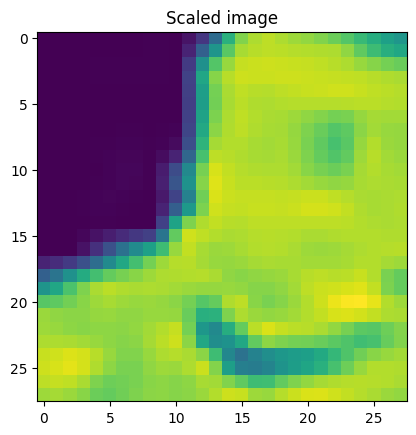

In [9]:
plt.imshow(aug.augment_image(to_numpy(tr_images[0])))
plt.title('Scaled image')
plt.show()

>在以上输出中，图像已被放大，但由于图像的输出形状没有改变，因此会从原始图像中删除一部分像素。

4. 使用 translate_px 参数执行图像平移：

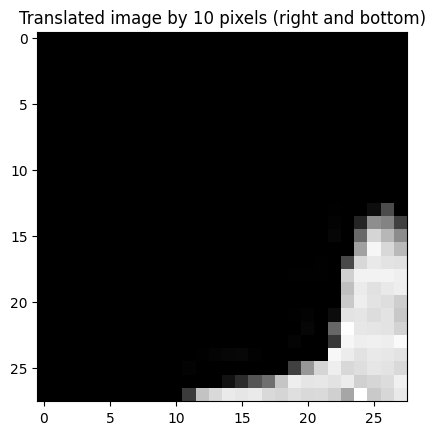

In [10]:
aug = iaa.Affine(translate_px=10)
plt.imshow(aug.augment_image(to_numpy(tr_images[0])), cmap='gray')
plt.title('Translated image by 10 pixels (right and bottom)')
plt.show()

- 在以上输出中，x 轴和 y 轴都平移了 10 个像素。如果两个轴上平移不同的像素量，则必须指定在每个轴上的平移量：

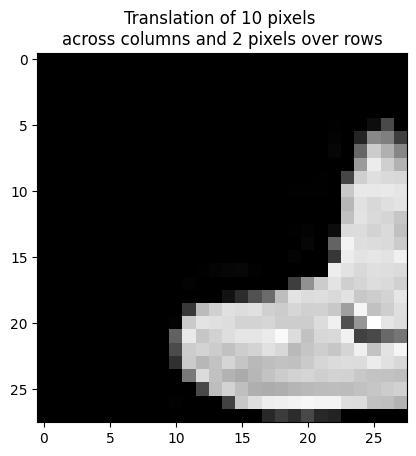

In [13]:
aug = iaa.Affine(translate_px={'x':10,'y':2})
plt.imshow(aug.augment_image(to_numpy(tr_images[0])), cmap='gray')
plt.title('Translation of 10 pixels \nacross columns and 2 pixels over rows')
plt.show()


在以上输出结果中，在 translate_px 参数中使用字典指定 x 和 y 轴的平移量，图像在 x 轴上平移了更多像素。

5. 观察旋转和剪切对图像增强的影响：

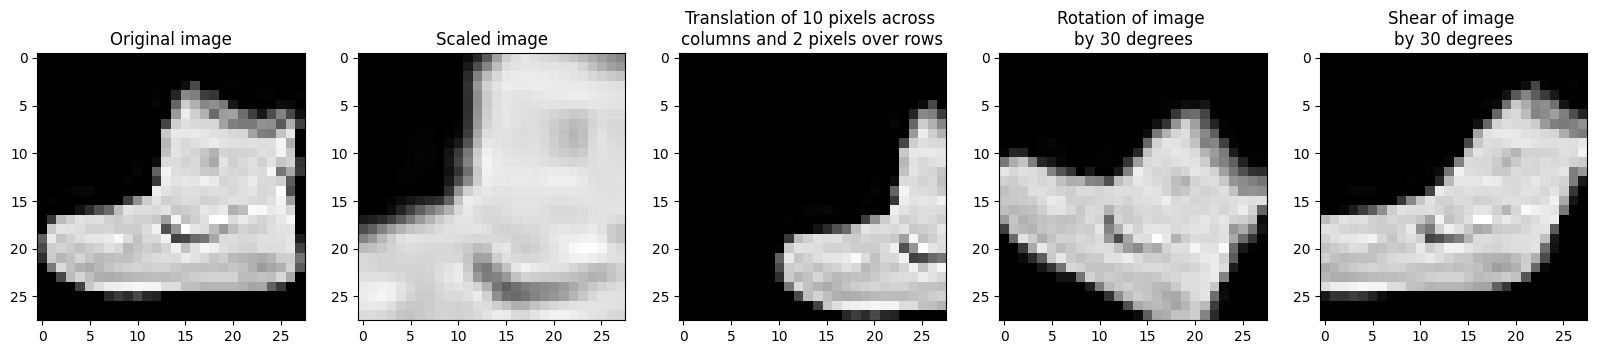

In [14]:
plt.figure(figsize=(20,20))
plt.subplot(151)
plt.imshow(tr_images[0], cmap='gray')
plt.title('Original image')
plt.subplot(152)
aug = iaa.Affine(scale=2)
plt.imshow(aug.augment_image(to_numpy(tr_images[0])), cmap='gray')
plt.title('Scaled image')
plt.subplot(153)
aug = iaa.Affine(translate_px={'x':10,'y':2})
plt.imshow(aug.augment_image(to_numpy(tr_images[0])), cmap='gray')
plt.title('Translation of 10 pixels across \ncolumns and 2 pixels over rows')
plt.subplot(154)
aug = iaa.Affine(rotate=30)
plt.imshow(aug.augment_image(to_numpy(tr_images[0])), cmap='gray')
plt.title('Rotation of image \nby 30 degrees')
plt.subplot(155)
aug = iaa.Affine(shear=30)
plt.imshow(aug.augment_image(to_numpy(tr_images[0])), cmap='gray')
plt.title('Shear of image \nby 30 degrees')
plt.show()

>在以上输出中，可以看到某些像素在转换后从图像中被裁剪掉。接下来，我们利用 Affine 方法中的 fit_output 参数确保图像不因裁剪丢失信息。默认情况下，fit_output 设置为 False，将 fit_output 指定为 True 时，观察在缩放、平移、旋转和剪切图像时，输出图像的变化：​

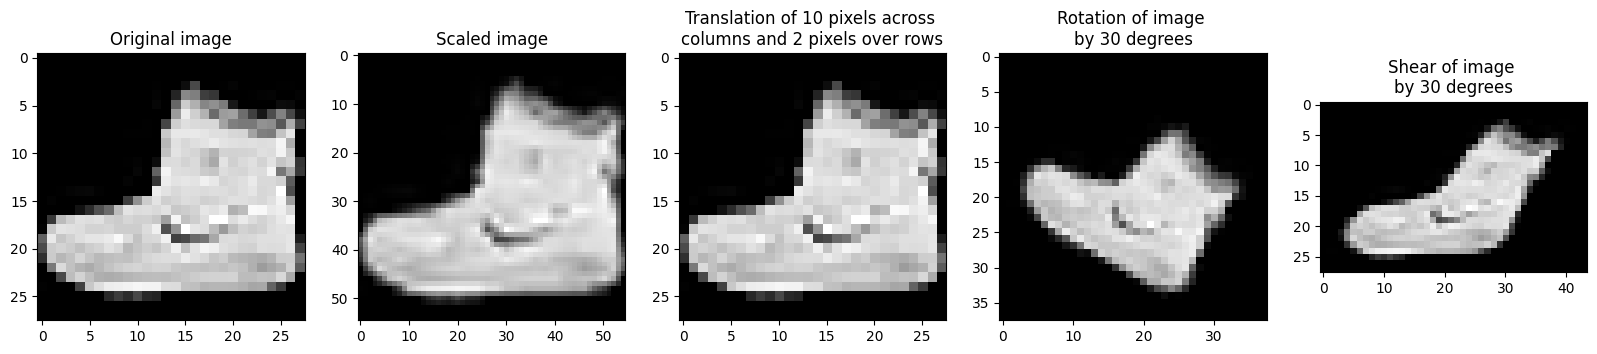

In [15]:
plt.figure(figsize=(20,20))
plt.subplot(151)
plt.imshow(tr_images[0], cmap='gray')
plt.title('Original image')
plt.subplot(152)
aug = iaa.Affine(scale=2, fit_output=True)
plt.imshow(aug.augment_image(to_numpy(tr_images[0])), cmap='gray')
plt.title('Scaled image')
plt.subplot(153)
aug = iaa.Affine(translate_px={'x':10,'y':2}, fit_output=True)
plt.imshow(aug.augment_image(to_numpy(tr_images[0])), cmap='gray')
plt.title('Translation of 10 pixels across \ncolumns and 2 pixels over rows')
plt.subplot(154)
aug = iaa.Affine(rotate=30, fit_output=True)
plt.imshow(aug.augment_image(to_numpy(tr_images[0])), cmap='gray')
plt.title('Rotation of image \nby 30 degrees')
plt.subplot(155)
aug = iaa.Affine(shear=30, fit_output=True)
plt.imshow(aug.augment_image(to_numpy(tr_images[0])), cmap='gray')
plt.title('Shear of image \nby 30 degrees')
plt.show()

>可以看到原始图像没有被裁剪，并且会增加图像的大小以进行完整显示。当增强图像的大小增加时，我们需要清楚如何填充不属于原始图像的新像素。

当 fit_output 为 True 时，使用 cval 参数指定创建的新像素的像素值。在以上代码中，cval 填充了默认值 0，即黑色像素，接下来，将 cval 参数改为 255，即白色像素，观察输出结果：

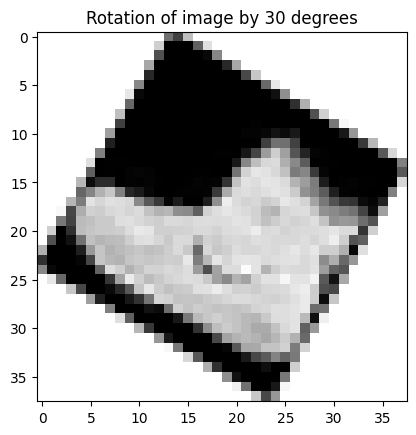

In [16]:
aug = iaa.Affine(rotate=30, fit_output=True, cval=255)
plt.imshow(aug.augment_image(to_numpy(tr_images[0])), cmap='gray')
plt.title('Rotation of image by 30 degrees')
plt.show()

此外，可以使用不同的模式来填充新创建的像素的值，mode 参数的可选值如下：

- constant：使用恒定值填充​
- edge：用输入的边缘值填充​
- symmetric：用沿输入边缘的反射填充​
- reflect：用反射向量填充​
- wrap：用沿轴的向量填充

将 cval 设置为 0 并使用不同 mode 参数：

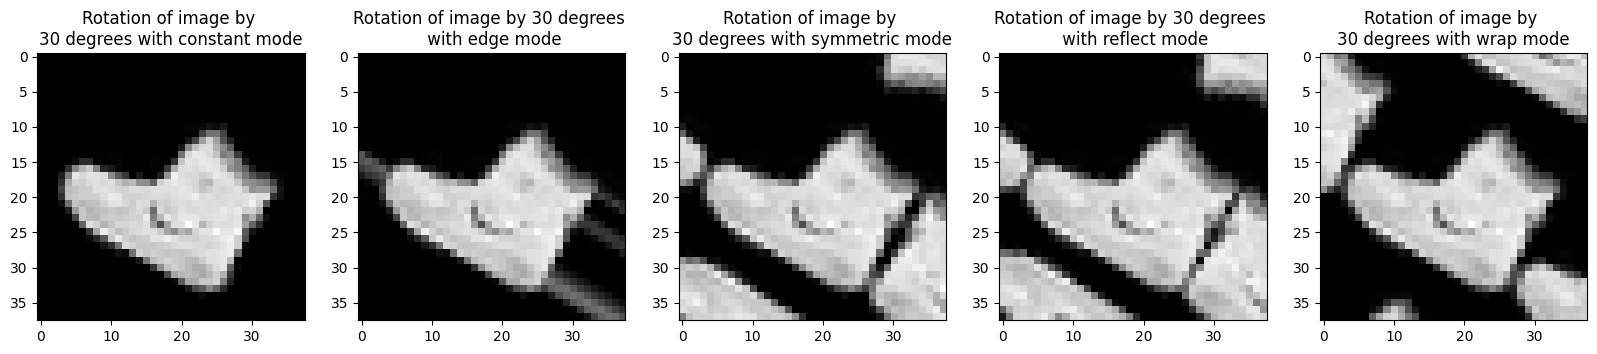

In [17]:
plt.figure(figsize=(20,20))
plt.subplot(151)
aug = iaa.Affine(rotate=30, fit_output=True, cval=0, mode='constant')
plt.imshow(aug.augment_image(to_numpy(tr_images[0])), cmap='gray')
plt.title('Rotation of image by \n30 degrees with constant mode')
plt.subplot(152)
aug = iaa.Affine(rotate=30, fit_output=True, cval=0, mode='edge')
plt.imshow(aug.augment_image(to_numpy(tr_images[0])), cmap='gray')
plt.title('Rotation of image by 30 degrees \n with edge mode')
plt.subplot(153)
aug = iaa.Affine(rotate=30, fit_output=True, cval=0, mode='symmetric')
plt.imshow(aug.augment_image(to_numpy(tr_images[0])), cmap='gray')
plt.title('Rotation of image by \n30 degrees with symmetric mode')
plt.subplot(154)
aug = iaa.Affine(rotate=30, fit_output=True, cval=0, mode='reflect')
plt.imshow(aug.augment_image(to_numpy(tr_images[0])), cmap='gray')
plt.title('Rotation of image by 30 degrees \n with reflect mode')
plt.subplot(155)
aug = iaa.Affine(rotate=30, fit_output=True, cval=0, mode='wrap')
plt.imshow(aug.augment_image(to_numpy(tr_images[0])), cmap='gray')
plt.title('Rotation of image by \n30 degrees with wrap mode')
plt.show()

在执行数据增强时，很难指定图像需要旋转的确切角度，通常提供图像将旋转的范围:

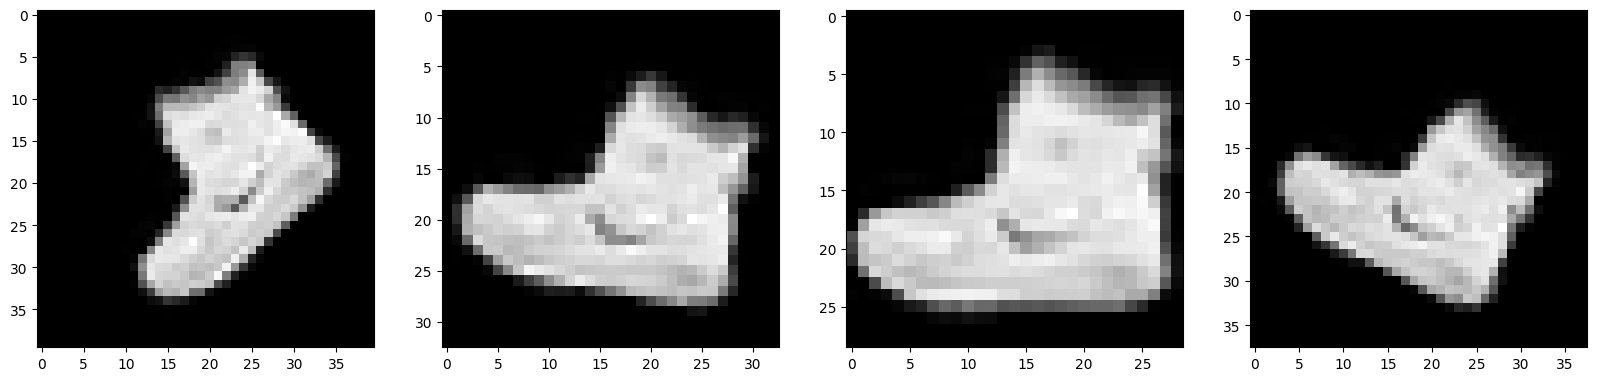

In [20]:
plt.figure(figsize=(20,20))
plt.subplot(141)
aug = iaa.Affine(rotate=(-45,45), fit_output=True, cval=0, mode='constant')
plt.imshow(aug.augment_image(to_numpy(tr_images[0])), cmap='gray')
plt.subplot(142)
aug = iaa.Affine(rotate=(-45,45), fit_output=True, cval=0, mode='constant')
plt.imshow(aug.augment_image(to_numpy(tr_images[0])), cmap='gray')
plt.subplot(143)
aug = iaa.Affine(rotate=(-45,45), fit_output=True, cval=0, mode='constant')
plt.imshow(aug.augment_image(to_numpy(tr_images[0])), cmap='gray')
plt.subplot(144)
aug = iaa.Affine(rotate=(-45,45), fit_output=True, cval=0, mode='constant')
plt.imshow(aug.augment_image(to_numpy(tr_images[0])), cmap='gray')
plt.show()

>在以上输出中，由于根据旋转的上限和下限指定了可能的旋转角度范围，相同的图像在不同的迭代中旋转角度不同。同样，我们可以在平移或缩放图像时引入随机化增强。

### 1.2 亮度修改

由于图像中的照明条件不同，背景和前景之间的差异有时并不明显。如果在训练模型时背景的像素值始终为 0，前景的像素值始终为 255，而预测图像的背景像素值为 20，前景像素值为 220，则预测很可能并不正确。乘法( Multiply )和线性对比度( Linearcontrast) 是两种不同的增强技术，可以解决照明条件不同的问题。

Multiply 方法将每个像素值乘以指定的值，例如将图像中的每个像素值乘以 0.5 后输出：

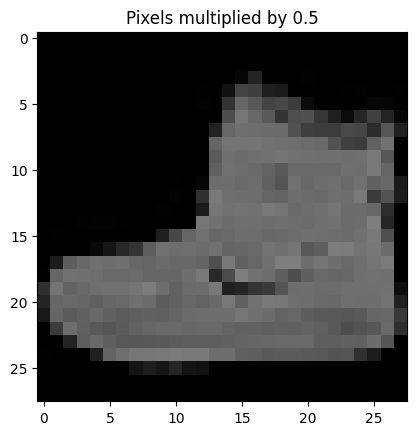

In [21]:
aug = iaa.Multiply(0.5)
plt.imshow(aug.augment_image(to_numpy(tr_images[0])), cmap='gray',vmin = 0, vmax = 255)
plt.title('Pixels multiplied by 0.5')
plt.show()

Linearcontrast 根据以下公式调整每个像素值：

$$
127 + \alpha \times (x_i - 127)
$$  
其中，$x_i$ 表示像素值，当 $\alpha$ 等于 **1** 时，像素值保持不变，当 $\alpha$ 小于 **1** 时，高像素值减少，低像素值增加。观察对输出图像的影响：

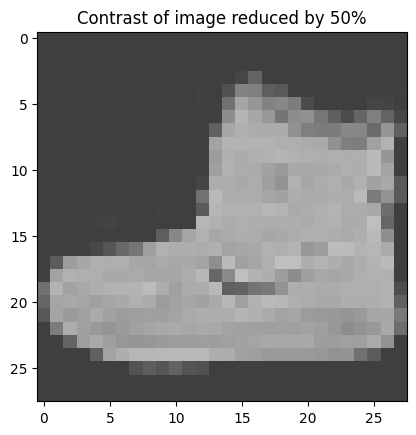

In [22]:
aug = iaa.LinearContrast(0.5)
plt.imshow(aug.augment_image(to_numpy(tr_images[0])), cmap='gray',vmin = 0, vmax = 255)
plt.title('Contrast of image reduced by 50%')
plt.show()

>可以看到，使用 Linearcontrast 方法，图像中的背景变得更加明亮，而前景像素的强度降低了。

使用 GaussianBlur 方法模糊图像以模拟真实场景(图像可能由于运动而模糊)：​
​

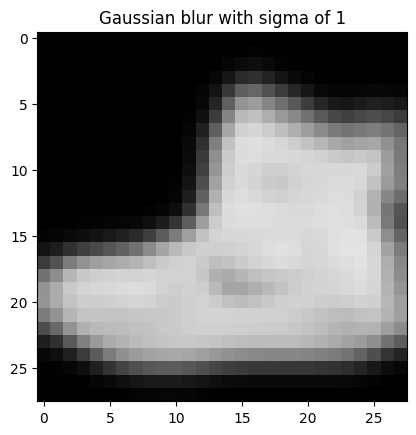

In [23]:
aug = iaa.GaussianBlur(sigma=1)
plt.imshow(aug.augment_image(to_numpy(tr_images[0])), cmap='gray',vmin = 0, vmax = 255)
plt.title('Gaussian blur with sigma of 1')
plt.show()

>可以看到图像非常模糊，并且随着 sigma 值的增加，图像也会变得更加模糊。

### 1.3 添加噪音  
在现实世界的场景中，可能会在图像中包含噪点，Dropout 和 SaltAndPepper 是用于模拟图像噪声的两种主要方法：

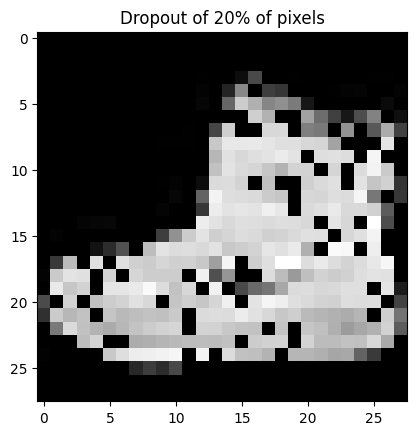

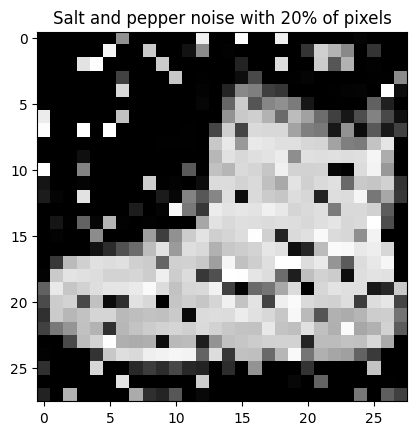

In [26]:
aug = iaa.Dropout(p=0.2)
plt.imshow(aug.augment_image(to_numpy(tr_images[0])), cmap='gray',vmin = 0, vmax = 255)
plt.title('Dropout of 20% of pixels')
plt.show()

aug = iaa.SaltAndPepper(0.2)
plt.imshow(aug.augment_image(to_numpy(tr_images[0])), cmap='gray',vmin = 0, vmax = 255)
plt.title('Salt and pepper noise with 20% of pixels')
plt.show()

>可以看到 Dropout 方法随机丢弃了一定数量的像素，即将它们的像素值转换为 0，而 SaltAndPepper 方法则在图像中随机添加白色和黑色的像素。

### 1.4 联合使用多个增强方法  
在现实世界的场景中，我们必须综合使用尽可能多的增强方法。在本节中，我们将了解图像增强的 Sequential 方式，在 Sequential 方法中可以使用需要执行的增强方法来构造图像增强。如果只考虑旋转和 Dropout 来增强图像，Sequential 对象如下所示：

In [27]:
seq = iaa.Sequential([
    iaa.Dropout(p=0.2,),
    iaa.Affine(rotate=(-30,30))], random_order= True)

在以上代码中，指定两种增强方法，并且使用 random_order 参数，指示采用随机顺序执行两种增强方法：

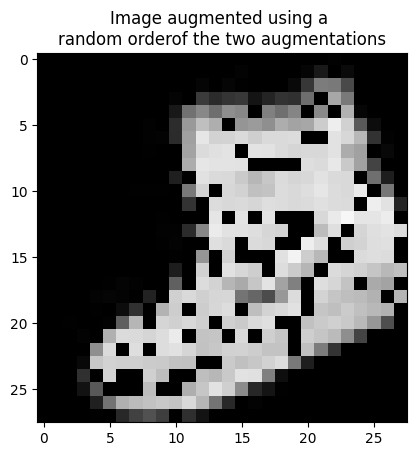

In [31]:
plt.imshow(seq.augment_image(to_numpy(tr_images[0])), cmap='gray',vmin = 0, vmax = 255)
plt.title('Image augmented using a \nrandom orderof the two augmentations')
plt.show()

## 2. 对批图像执行图像增强  
为了最大限度的提高模型性能，需要同一图像在不同迭代中执行不同的增强。如果我们在 init 方法中定义了一个增强管道，则只需要对输入图像集执行一次增强，这意味着在不同的迭代中不会有不同的增强；如果增强是在 getitem 方法中，会对每个图像执行一组不同的增强，对每个图像执行一次增强。如果每次对一批图像而不是一次对一个图像执行增强，可以提高算法执行效率，接下来，我们对比以下两种方案：

- 一次对一张图像执行增强，得到 32 张图像
- 一次对一批图像执行增强，得到 32 张图像

为了了解在这两种情况下执行图像增强所需的时间，利用 Fashion-MNIST 数据集的训练图像中的前 32 张图像。

1. 获取训练数据集中的前 32 张图像：

In [32]:
from torchvision import datasets
import torch
device = 'cpu'
import time

data_folder = './data/MNIST'
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)

tr_images = fmnist.data
tr_targets = fmnist.targets

def to_numpy(tensor):
    return tensor.cpu().detach().numpy()

2. 指定要对图像执行的增强：

In [33]:
from imgaug import augmenters as iaa
aug = iaa.Sequential([
    iaa.Affine(translate_px={'x':(-10,10)}, mode='constant'),
])

- 接下来，介绍如何在 Dataset 类中扩充数据，有两种方法来扩充数据：
  - 每次增强一批数据中的一张图像
  - 一次性增强一批数据中的所有图像  

增强批数据中的32张图像，一次一张

- 使用 augment_image 方法，计算增强批数据中的 32 张图像(一次增强一张)所需的时间：

In [34]:
start = time.time()
for i in range(32):
    aug.augment_image(to_numpy(tr_images[i]))
print('total times: ', time.time()-start)

total times:  0.03685617446899414


- 使用 augment_images 方法，计算一次性增强 32 张图像所需的时间：

In [42]:
start = time.time()
x = aug.augment_images(to_numpy(tr_images[:32]))
print('total times: ', time.time()-start)

total times:  0.006754398345947266


>因此，最佳实践是在一批图像之上执行增强，而不是一次增强一个图像，augment_images 方法的输出是一个 numpy 数组。但是，之前使用的 Dataset 类在 getitem 方法中一次提供一张图像的索引。因此，需要创建一个新函数 collate_fn，使我们能够对一批图像执行操作。

3. 定义 Dataset 类，将输入图像、类别和增强对象作为初始化器：

In [47]:
class FMNISTDataset(Dataset):
    def __init__(self, x, y, aug=None):
        self.x, self.y = x, y
        self.aug = aug
    def __len__(self):
        return len(self.x)
    def __getitem__(self, idx):
        x, y = self.x[idx], self.y[idx]
        return x, y
    
    #定义 collate_fn 函数，将批数据作为输入：
    def collate_fn(batch):
        ims, classes = list(zip(*batch))#将批数据中的图像和标签分开
        if self.aug:
            ims=self.aug.augment_images(images=list(map(to_numpy,list(ims))))#如果定义了数据增强，则对图像进行增强,因为我们只需要对训练数据执行增强，而验证数据无需执行增强
        ims = torch.tensor(ims)[:,None,:,:].to(device)/255.#将图像转换为张量，并进行归一化
        classes = torch.tensor(classes).to(device)#将标签转换为张量
        return ims, classes

>在以上代码中，使用 augment_images 方法，以便可以一次性处理一批图像。  
>一般来说，当我们需要执行复杂计算时，会利用 collate_fn 方法，这是因为一次性对一批图像执行计算比一次执行一个图像要快得多。

5. 为了利用 collate_fn 方法，在创建 DataLoader 时使用一个新参数。​
首先，创建 train 对象：

In [48]:
train = FMNISTDataset(tr_images, tr_targets, aug=aug)

接下来，定义 DataLoader 以及对象的 collate_fn 方法：

In [49]:
trn_dl = DataLoader(train, batch_size=64,
                    collate_fn=train.collate_fn, shuffle=True)

最后，训练模型，通过利用 collate_fn 方法，可以更快地训练模型。

## 3. 利用数据增强训练模型  
接下来，我们使用增强数据训练模型，观察数据增强对模型训练的影响。

1. 导入相关库和数据集：

In [50]:
from torchvision import datasets
from torch.utils.data import Dataset, DataLoader
import torch
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
device = 'cpu'

data_folder = './data/MNIST'
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)

tr_images = fmnist.data
tr_targets = fmnist.targets

val_fmnist = datasets.FashionMNIST(data_folder, download=True, train=False)
val_images = val_fmnist.data
val_targets = val_fmnist.targets

2. 创建数据集类，用于随机平移图像执行数据增强：

- 定义数据增强管道：

In [52]:
from imgaug import augmenters as iaa
aug = iaa.Sequential([
    iaa.Affine(translate_px={'x':(-10,10)},
                    mode='constant'),
])

- 定义数据类

In [62]:
def to_numpy(tensor):
    return tensor.numpy()

class FMNISTDataset(Dataset):
    def __init__(self, x, y, aug=None):
        self.x, self.y = x, y
        self.aug = aug
    def __len__(self):
        return len(self.x)
    def __getitem__(self, idx):
        x, y = self.x[idx], self.y[idx]
        return x, y
    
    #定义 collate_fn 函数，将批数据作为输入：
    def collate_fn(self, batch):
        'logic to modify a batch of images'
        ims, classes = list(zip(*batch))
        if self.aug:
            ims=self.aug.augment_images(images=list(map(to_numpy,list(ims))))
        ims = torch.tensor(ims)[:,None,:,:].to(device)/255.
        classes = torch.tensor(classes).to(device)
        return ims, classes

在以上代码中，利用 collate_fn 方法来指定要对批图像执行增强。

3. 定义模型架构：

In [63]:
from torch.optim import SGD, Adam
def get_model():
    model = nn.Sequential(
        nn.Conv2d(1, 64, kernel_size=3),
        nn.MaxPool2d(2),
        nn.ReLU(),
        nn.Conv2d(64, 128, kernel_size=3),
        nn.MaxPool2d(2),
        nn.ReLU(),
        nn.Flatten(),
        nn.Linear(3200, 256),
        nn.ReLU(),
        nn.Linear(256, 10)
    ).to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-3)
    return model, loss_fn, optimizer

4. 定义 train_batch 函数以在批数据上训练模型：

In [64]:
def train_batch(x, y, model, optimizer, loss_fn):
    prediction = model(x)
    batch_loss = loss_fn(prediction, y)
    batch_loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    return batch_loss.item()

5. 定义 get_data 函数获取训练和验证 DataLoaders：

In [65]:
def get_data():
    train = FMNISTDataset(tr_images, tr_targets, aug=aug)
    'notice the collate_fn argument'
    trn_dl = DataLoader(train, batch_size=64,
                        collate_fn=train.collate_fn, shuffle=True)
    val = FMNISTDataset(val_images, val_targets)
    val_dl = DataLoader(val, batch_size=len(val_images),
                        collate_fn=val.collate_fn, shuffle=True)
    return trn_dl, val_dl

6. 指定训练和验证 DataLoaders 并获取模型对象、损失函数和优化器:

In [66]:
trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()

7. 训练模型：

In [67]:
for epoch in range(10):
    print(epoch)
    for idx, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)

0


C:\Users\Admin\AppData\Local\Temp\ipykernel_43068\2281230747.py:20: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_new.cpp:281.)
  ims = torch.tensor(ims)[:,None,:,:].to(device)/255.


1
2
3
4
5
6
7
8
9


8. 在平移图像上测试模型：

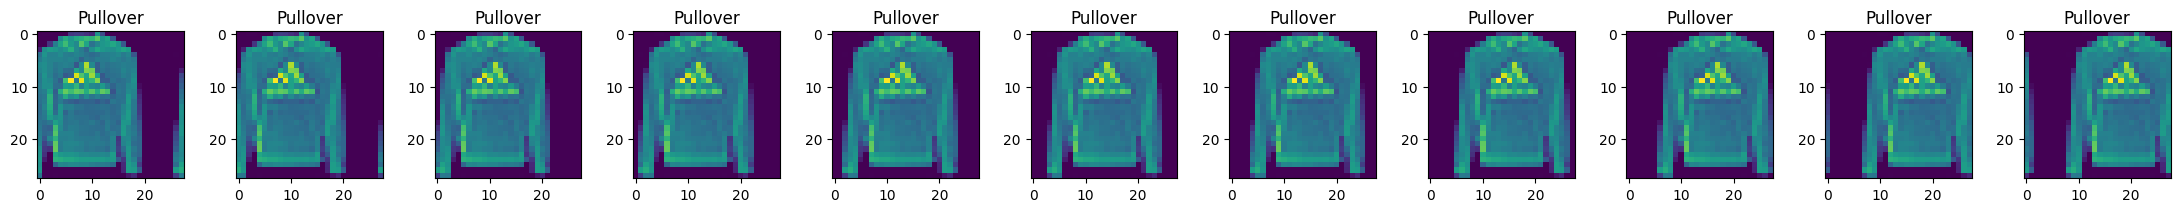

In [71]:
preds = []
ix = 24150

plt.figure(figsize=(22, 2))  # 先创建画布，避免子图重叠

for px in range(-5, 6):
    img = tr_images[ix]/255.
    img = img.view(28, 28)
    plt.subplot(1, 11, px+6)
    img2 = np.roll(img, px, axis=1)
    img3 = torch.Tensor(img2).view(-1,1,28,28).to(device)
    np_output = model(img3).cpu().detach().numpy()
    pred = np.exp(np_output)/np.sum(np.exp(np_output))
    preds.append(pred)
    plt.imshow(img2)
    
    plt.title(fmnist.classes[pred[0].argmax()])
    
plt.tight_layout()  
plt.show()

- 绘制模型关于平移图形的预测类别变化：

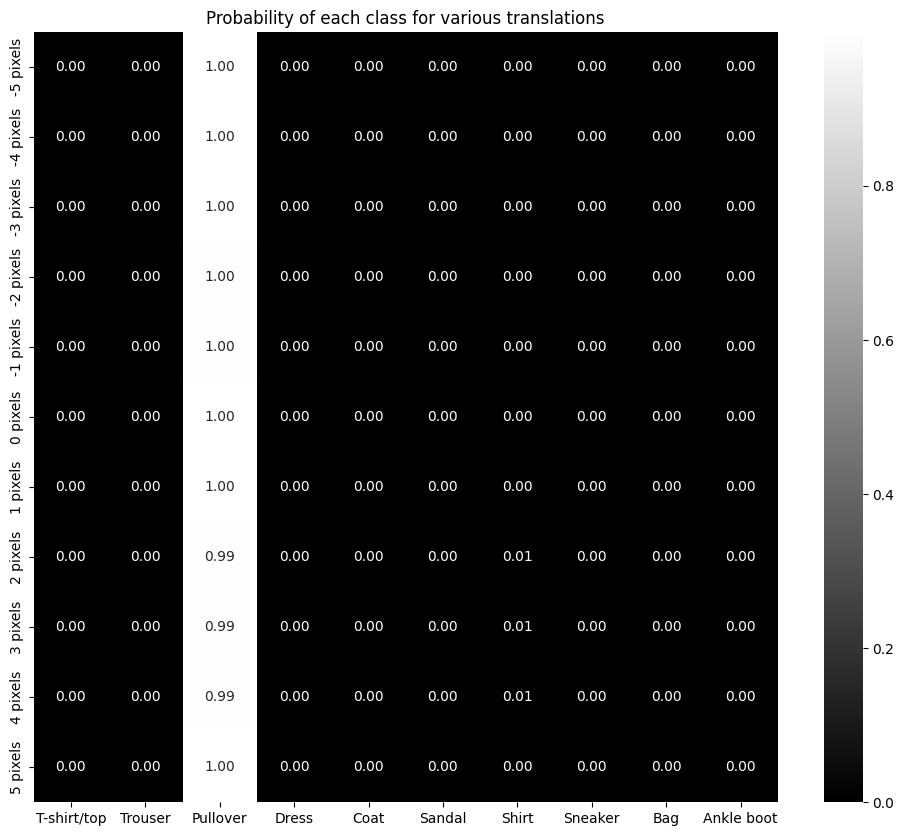

In [73]:
import seaborn as sns
fig, ax = plt.subplots(1,1, figsize=(12,10))
plt.title('Probability of each class for various translations')
sns.heatmap(np.array(preds).reshape(11,10), annot=True, ax=ax, fmt='.2f', xticklabels=fmnist.classes, yticklabels=[str(i)+str(' pixels') for i in range(-5,6)], cmap='gray')
plt.show()

>可以看到，当我们预测各种平移图像时，模型能够以极高的置信度预测图像的正确类别。

## 小结  
数据增强是一种有效的提升模型性能的方法，通过扩充训练数据集和增加数据的多样性，可以提高模型的泛化能力和鲁棒性。在实际应用中，可以根据需求选择适当的数据增强方法，并进行合理的参数设置，以获得更好的训练效果。imgaug 是一个用于机器学习中图像增强的 Python 库，它支持多种增强技术，能够轻松组合这些技术，且有丰富的文档支持，能满足大多数的数据增强的需求。本节中，介绍了图像增强的基本概念，并使用 imgaug 介绍了常见的图像增强技术，通过实验表明使用图像增强能够显著提高神经网络模型性能。